In [39]:
# Source:
# video: https://www.youtube.com/watch?v=w6bOBZX-1kY
# code: https://github.com/mGalarnyk/Python_Tutorials/blob/master/Sklearn/KNN/KNN.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# For scaling data
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn import metrics

In [40]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Arrange Data into Features Matrix and Target Vector

For demonstrational purposes, we are going take two features 

In [41]:
X = df.loc[:, ['sepal length (cm)', 'sepal width (cm)']]
#X = df.loc[:, df.columns != 'target']

In [42]:
X.shape

(150, 2)

In [43]:
y = df.loc[:, 'target'].values

In [44]:
y.shape

(150,)

### Split the data into training and testing sets

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0,
                                                    test_size = .2)

### KNN in `scikit-learn`

<b>Step 1:</b> Import the model you want to use

In sklearn, all machine learning models are implemented as Python classes

In [46]:
from sklearn.neighbors import KNeighborsClassifier

<b>Step 2:</b> Make an instance of the Model

In [47]:
knn = KNeighborsClassifier(n_neighbors=5)

In [48]:
print(knn)

KNeighborsClassifier()


<b>Step 3:</b> Train the model on the data, storing the information learned from the data. Model is learning the relationship between features and labels

In [49]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

<b>Step 4:</b> Predict the labels of new data

Uses the information the model learned during the model training process

In [50]:
predictions = knn.predict(X_test)

In [51]:
predictions

array([1, 1, 0, 2, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 1, 0, 0, 1, 1,
       0, 0, 2, 0, 0, 2, 1, 0])

In [52]:
# calculate classification accuracy
score = knn.score(X_test, y_test)

In [53]:
score

0.6666666666666666

### Visualizing Data

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, '3-Class classification (k = 5)')

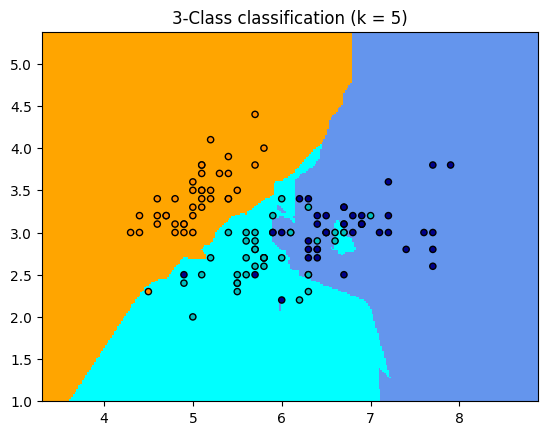

In [54]:
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])
h = .02  # step size in the mesh


# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X_train.loc[:, 'sepal length (cm)'].values.min() - 1, X_train.loc[:, 'sepal length (cm)'].values.max() + 1
y_min, y_max = X_train.loc[:, 'sepal width (cm)'].values.min() - 1, X_train.loc[:, 'sepal width (cm)'].values.max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='nearest')

# Plot also the training points
plt.scatter(X_train.loc[:, 'sepal length (cm)'].values,
            X_train.loc[:, 'sepal width (cm)'].values,
            c=y_train,
            cmap=cmap_bold,
            edgecolor='k',
            s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("3-Class classification (k = 5)")

In [55]:
xx.shape

(220, 280)

### Visualizing Data (YouTube Thumbnail)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


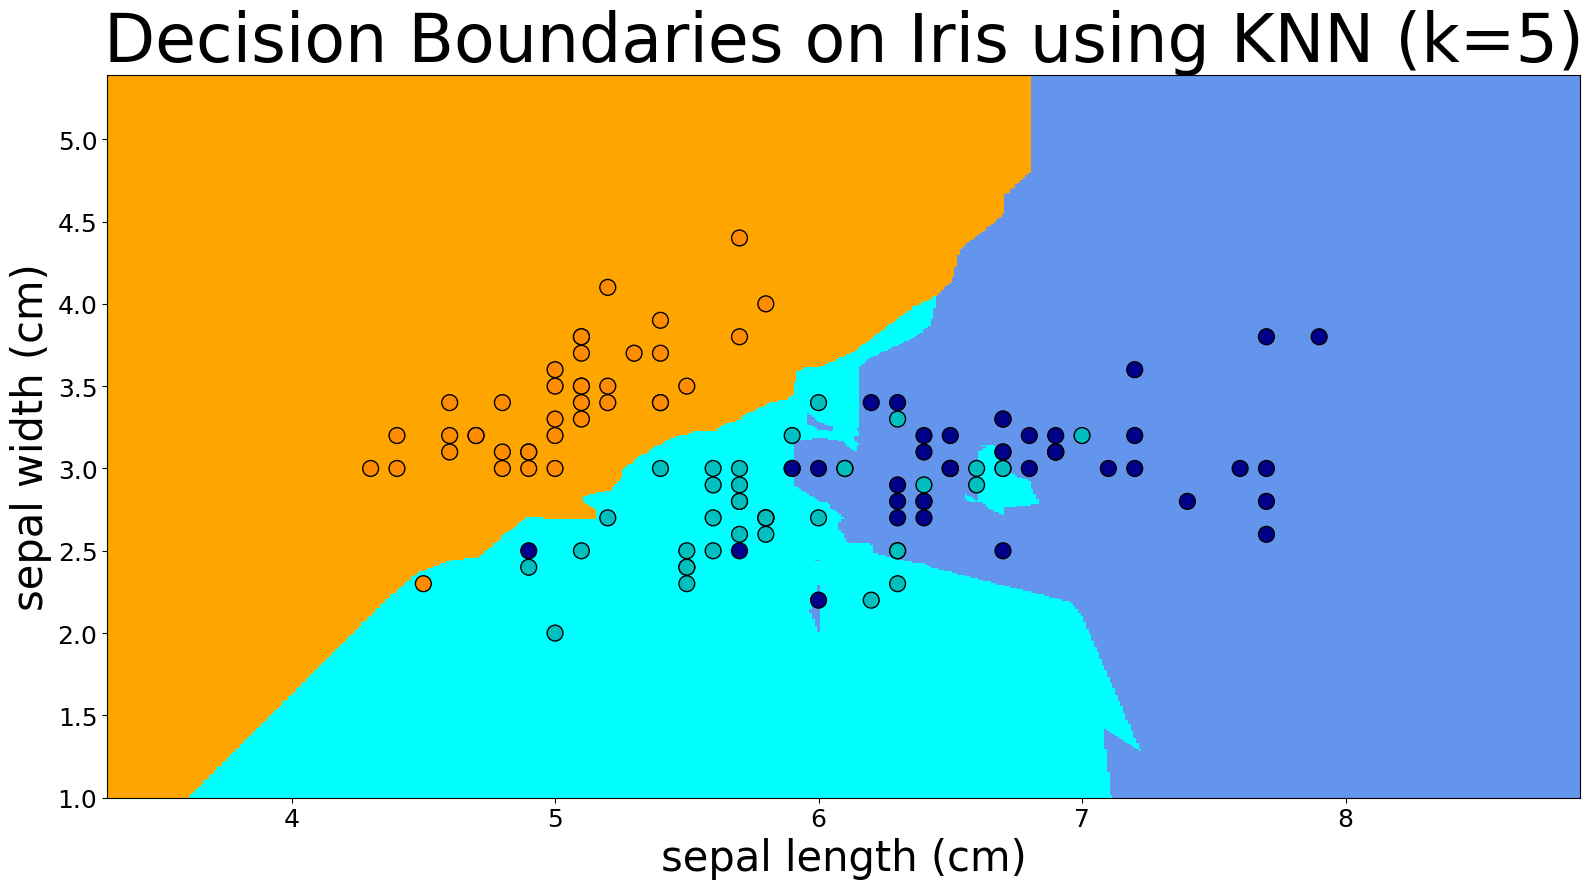

In [56]:
# Define the color maps
cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])
h = .01  # step size in the mesh

# Create figure and axes with specified size and white background
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 9), facecolor='white')

# Determine the min and max values for x and y
x_min, x_max = X_train.loc[:, 'sepal length (cm)'].values.min() - 1, X_train.loc[:, 'sepal length (cm)'].values.max() + 1
y_min, y_max = X_train.loc[:, 'sepal width (cm)'].values.min() - 1, X_train.loc[:, 'sepal width (cm)'].values.max() + 1

# Create a mesh grid
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict class using the mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
ax.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='nearest')

# Plot also the training points
ax.scatter(X_train.loc[:, 'sepal length (cm)'].values,
           X_train.loc[:, 'sepal width (cm)'].values,
           c=y_train,
           cmap=cmap_bold,
           edgecolor='k',
           s=130)

# Set the limits of the plot
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())

ax.tick_params(labelsize = 18)

ax.set_xlabel('sepal length (cm)', fontsize = 30)
ax.set_ylabel('sepal width (cm)', fontsize = 30)
ax.set_title("Decision Boundaries on Iris using KNN (k=5)", fontsize = 48)

fig.tight_layout()
#fig.savefig('KNN_3_Class_Classification.png', dpi = 950)